In [ ]:
import platform
import warnings
import matplotlib.pyplot as plt
import numpy as np

# 1. 폰트 글자 부족으로 인한 UserWarning 경고 메시지 강제 차단 
warnings.filterwarnings(action="ignore", category=UserWarning)

# 2. OS별 기본 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 3. 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [14]:
# 입력 값 x1 = 1, x2 = 0
x = np.array([1, 0])
# 가중치 w
w = np.array([0.6, 0.4])
# 편향
b = -0.5

# z 값 =  가중합  + 편향, z = wx + b
z = np.dot(w, x) + b
z

np.float64(0.09999999999999998)

In [15]:
# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [16]:
sigmoid(z)

np.float64(0.5249791874789399)

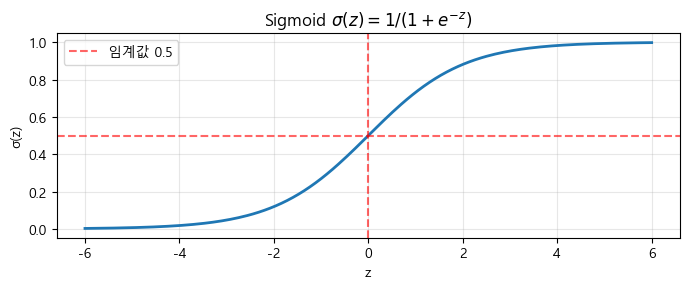

In [19]:
z_range = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 3))
plt.plot(z_range, sigmoid(z_range), lw=2)
plt.axhline(0.5, color="r", linestyle="--", alpha=0.6, label="임계값 0.5")
plt.axvline(0, color="r", linestyle="--", alpha=0.6)
plt.title(r"Sigmoid $\sigma(z) = 1 / (1 + e^{-z})$")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
def perceptron(x, w, b, threshold=0.5):
    z = np.dot(w, x) + b
    a = sigmoid(z)
    pred = int(a > threshold)
    return pred, a, z

---
AND 게이트

In [24]:
w_and = np.array([1.0, 1.0])
b_and = -1.5

inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
targets = [0, 0, 0, 1]

print("AND 게이트  (w=[1,1], b=-1.5)")
print(
    f"{'x1':>3} {'x2':>3} │ {'z':>6}  {'σ(z)':>6}  {'예측':>4}  {'정답':>4}  {'✓/✗':>4}"
)
print("─" * 45)
for (x1, x2), t in zip(inputs, targets):
    pred, a, z = perceptron(np.array([x1, x2]), w_and, b_and)
    ok = "✓" if pred == t else "✗"
    print(f"  {x1}   {x2}  │ {z:>6.1f}  {a:>6.3f}  {pred:>4}  {t:>4}  {ok:>4}")

AND 게이트  (w=[1,1], b=-1.5)
 x1  x2 │      z    σ(z)    예측    정답   ✓/✗
─────────────────────────────────────────────
  0   0  │   -1.5   0.182     0     0     ✓
  0   1  │   -0.5   0.378     0     0     ✓
  1   0  │   -0.5   0.378     0     0     ✓
  1   1  │    0.5   0.622     1     1     ✓



---
OR 게이트

In [25]:
w_or = np.array([1.0, 1.0])
b_or = -0.5

inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
targets = [0, 1, 1, 1]

print("OR 게이트  (w=[1,1], b=-0.5)")
print(
    f"{'x1':>3} {'x2':>3} │ {'z':>6}  {'σ(z)':>6}  {'예측':>4}  {'정답':>4}  {'✓/✗':>4}"
)
print("─" * 45)
for (x1, x2), t in zip(inputs, targets):
    pred, a, z = perceptron(np.array([x1, x2]), w_or, b_or)
    ok = "✓" if pred == t else "✗"
    print(f"  {x1}   {x2}  │ {z:>6.1f}  {a:>6.3f}  {pred:>4}  {t:>4}  {ok:>4}")

OR 게이트  (w=[1,1], b=-0.5)
 x1  x2 │      z    σ(z)    예측    정답   ✓/✗
─────────────────────────────────────────────
  0   0  │   -0.5   0.378     0     0     ✓
  0   1  │    0.5   0.622     1     1     ✓
  1   0  │    0.5   0.622     1     1     ✓
  1   1  │    1.5   0.818     1     1     ✓


In [27]:
# b 값에 따른 활성화 기준 변화
print("편향에 따른 σ(z) at x=[1,1]:")
for b_val in [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5]:
    z = 1 + 1 + b_val  # w=[1,1], x=[1,1] → z = 2+b
    a = sigmoid(z)
    print(f"  b={b_val:+.1f} → z={z:+.1f} → σ={a:.3f}  {'← 활성화' if a>=0.5 else ''}")

편향에 따른 σ(z) at x=[1,1]:
  b=-2.0 → z=+0.0 → σ=0.500  ← 활성화
  b=-1.5 → z=+0.5 → σ=0.622  ← 활성화
  b=-1.0 → z=+1.0 → σ=0.731  ← 활성화
  b=-0.5 → z=+1.5 → σ=0.818  ← 활성화
  b=+0.0 → z=+2.0 → σ=0.881  ← 활성화
  b=+0.5 → z=+2.5 → σ=0.924  ← 활성화


b가 작을수록 더 까다로운 조건에 활성화가 되고, b가 클수록 쉽게 활성화가 된다.


---
XOR은 단층 퍼셉트론으로 불가능

In [28]:
# XOR 한계
targets_xor = [0, 1, 1, 0]


def test_gate(w, b, label):
    correct = 0
    for (x1, x2), t in zip(inputs, targets_xor):
        pred, _, _ = perceptron(np.array([x1, x2]), w, b)
        correct += pred == t
    print(f"  {label}: {correct}/4 correct  {'✓ 성공!' if correct==4 else '✗'}")


print("XOR 게이트 — 다양한 w, b 시도:")
test_gate(np.array([1.0, 1.0]), 0.0, "w=[ 1, 1], b= 0.0")
test_gate(np.array([1.0, -1.0]), 0.0, "w=[ 1,-1], b= 0.0")
test_gate(np.array([2.0, -1.0]), -0.5, "w=[ 2,-1], b=-0.5")
test_gate(np.array([-1.0, 2.0]), 0.0, "w=[-1, 2], b= 0.0")
print()

XOR 게이트 — 다양한 w, b 시도:
  w=[ 1, 1], b= 0.0: 3/4 correct  ✗
  w=[ 1,-1], b= 0.0: 3/4 correct  ✗
  w=[ 2,-1], b=-0.5: 2/4 correct  ✗
  w=[-1, 2], b= 0.0: 2/4 correct  ✗



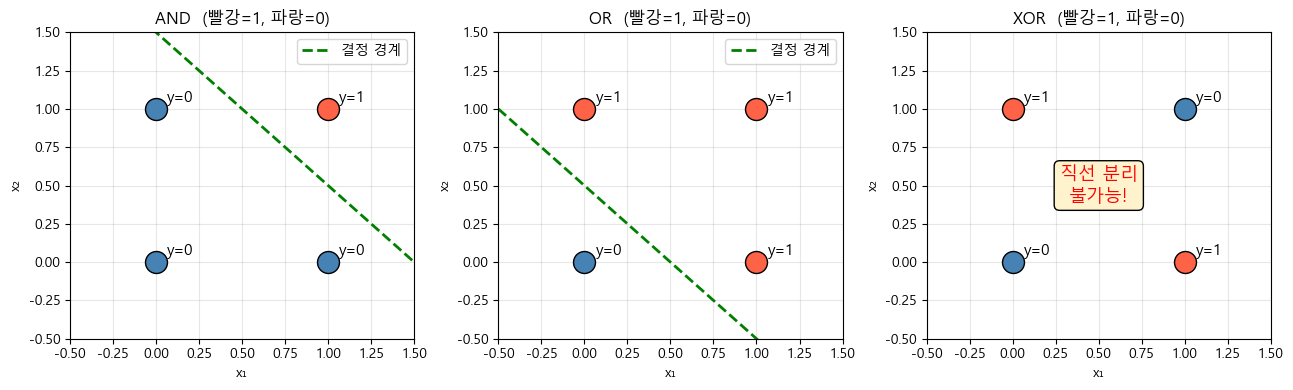

In [29]:
points = [(0, 0), (0, 1), (1, 0), (1, 1)]
and_labels = [0, 0, 0, 1]
or_labels = [0, 1, 1, 1]
xor_labels = [0, 1, 1, 0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, labels, title in zip(
    axes, [and_labels, or_labels, xor_labels], ["AND", "OR", "XOR"]
):
    for (x1, x2), y in zip(points, labels):
        ax.scatter(
            x1,
            x2,
            c="tomato" if y == 1 else "steelblue",
            s=250,
            zorder=3,
            edgecolors="k",
        )
        ax.annotate(
            f"y={y}", (x1, x2), textcoords="offset points", xytext=(8, 5), fontsize=11
        )
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{title}  (빨강=1, 파랑=0)", fontsize=12)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.grid(True, alpha=0.3)
    # AND, OR는 분리선 그리기
    x_line = np.linspace(-0.5, 1.5, 100)
    if title == "AND":
        ax.plot(x_line, 1.5 - x_line, "g--", lw=2, label="결정 경계")
        ax.legend(fontsize=10)
    elif title == "OR":
        ax.plot(x_line, 0.5 - x_line, "g--", lw=2, label="결정 경계")
        ax.legend(fontsize=10)
    else:
        ax.text(
            0.5,
            0.5,
            "직선 분리\n불가능!",
            ha="center",
            va="center",
            fontsize=13,
            color="red",
            bbox=dict(boxstyle="round", facecolor="#fff3cd"),
        )
plt.tight_layout()
plt.show()

In [30]:
inputs = [
    np.array([0, 0]),
    np.array([0, 1]),
    np.array([1, 0]),
    np.array([1, 1]),
]

X = np.array(inputs)
y_xor = np.array([0, 1, 1, 0])


# 논리 게이트 함수
def AND(x):
    w = np.array([1.0, 1.0])
    b = -1.5
    pred, a, z = perceptron(x, w, b)
    return pred, a, z


def OR(x):
    w = np.array([1.0, 1.0])
    b = -0.5
    pred, a, z = perceptron(x, w, b)
    return pred, a, z


def NAND(x):
    w = np.array([-1.0, -1.0])
    b = 1.5
    pred, a, z = perceptron(x, w, b)
    return pred, a, z


def XOR(x):
    # 은닉층 1번 뉴런: OR
    or_pred, or_a, or_z = OR(x)

    # 은닉층 2번 뉴런: NAND
    nand_pred, nand_a, nand_z = NAND(x)

    # 은닉층 출력
    hidden = np.array([or_pred, nand_pred])

    # 출력층 뉴런: AND
    xor_pred, xor_a, xor_z = AND(hidden)

    return {
        "x": x,
        "or_pred": or_pred,
        "or_a": or_a,
        "or_z": or_z,
        "nand_pred": nand_pred,
        "nand_a": nand_a,
        "nand_z": nand_z,
        "hidden": hidden,
        "xor_pred": xor_pred,
        "xor_a": xor_a,
        "xor_z": xor_z,
    }

In [31]:
# XOR 진리표
print("XOR by Multi-Layer Perceptron")
print(f"{'x1':>3} {'x2':>3} | {'OR':>3} {'NAND':>5} | {'XOR':>3}")
print("-" * 32)

for x in inputs:
    result = XOR(x)

    print(
        f"{x[0]:>3} {x[1]:>3} | "
        f"{result['or_pred']:>3} {result['nand_pred']:>5} | "
        f"{result['xor_pred']:>3}"
    )

XOR by Multi-Layer Perceptron
 x1  x2 |  OR  NAND | XOR
--------------------------------
  0   0 |   0     1 |   0
  0   1 |   1     1 |   1
  1   0 |   1     1 |   1
  1   1 |   1     0 |   0
